In [1]:
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from pathlib import Path
from dataclasses import dataclass
from collections import Counter
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter, medfilt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid") 

@dataclass
class RawFileData:
    path: str 
    file_id: str
    class_name: str
    region: str
    center: str
    waves: np.ndarray
    intensities: np.ndarray

cache_files = list(Path("/kaggle/input").rglob("*.joblib")) + list(Path("/kaggle/working").rglob("*.joblib"))
if not cache_files:
    raise FileNotFoundError("Cache file .joblib not found.")
CACHE_PATH = str(cache_files[0])

OUTPUT_DIR = Path("/kaggle/working/output_final_presentation")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CLASS_DIR_TO_LABEL = {"control": "control", "endo": "endo_hsp70", "exo": "exo_hsp70"}

raw_data = joblib.load(CACHE_PATH)
print(f"Loaded {len(raw_data)} files from cache.")

def preprocess_spectra_advanced(matrix: np.ndarray, center: str) -> tuple[np.ndarray, np.ndarray]:
    """Смерть шуму: Медиана + Савицкий-Голей (без производной) + SNV"""
    mean_intensities = np.mean(matrix, axis=1)
    threshold = np.percentile(mean_intensities, 5) 
    valid_mask = mean_intensities > threshold
    filtered = matrix[valid_mask]

    despiked = medfilt(filtered, kernel_size=(1, 3))

    smoothed = savgol_filter(despiked, window_length=15, polyorder=3, deriv=0, axis=1)
    mean = smoothed.mean(axis=1, keepdims=True)
    std = smoothed.std(axis=1, keepdims=True)
    std[std < 1e-8] = 1.0 
    processed = (smoothed - mean) / std
    
    return processed, valid_mask

Loaded 237 files from cache.


Loading data for spectral visualization...


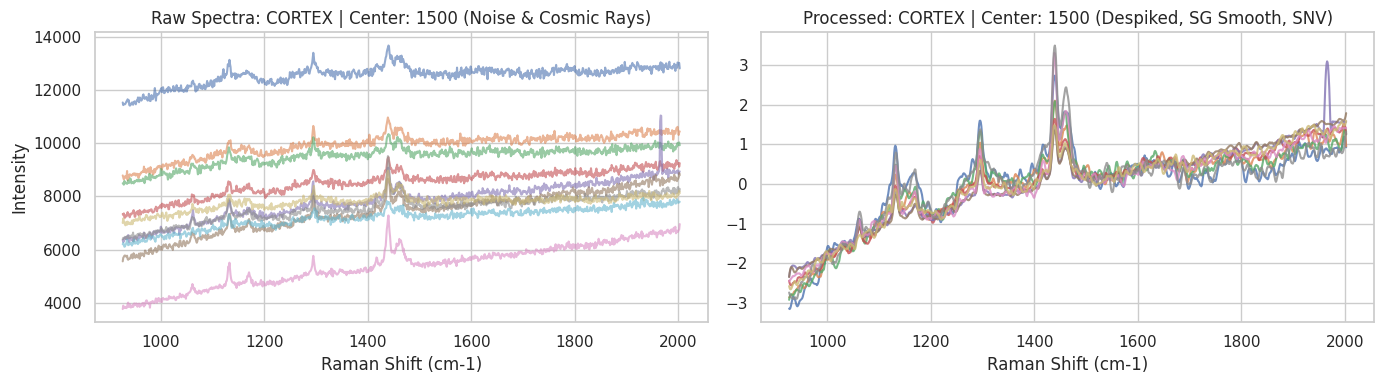

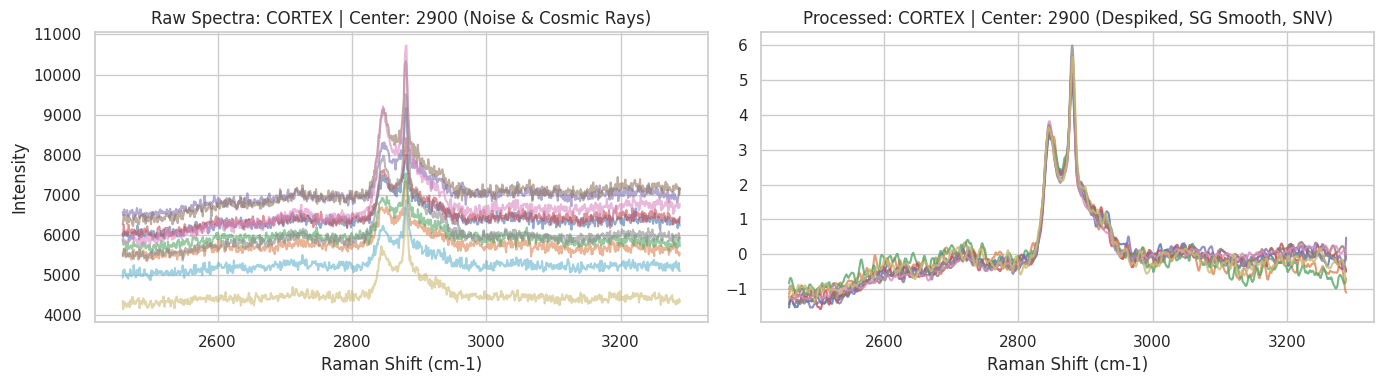

In [2]:
print("Loading data for spectral visualization...")

sample_1500 = next((f for f in raw_data if f.center == "1500"), None)
sample_2900 = next((f for f in raw_data if f.center == "2900"), None)

def plot_spectra_comparison(sample, title):
    if sample is None: return
    raw_intensities = sample.intensities[:10] 
    common_axis = np.linspace(sample.waves.min(), sample.waves.max(), 1024)

    f = interp1d(sample.waves, raw_intensities, axis=1)
    raw_aligned = f(common_axis)
    
    processed_intensities, _ = preprocess_spectra_advanced(raw_aligned, sample.center)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    
    for i in range(len(raw_aligned)):
        ax1.plot(common_axis, raw_aligned[i], alpha=0.6)
    ax1.set_title(f"Raw Spectra: {title} (Noise & Cosmic Rays)")
    ax1.set_xlabel("Raman Shift (cm-1)")
    ax1.set_ylabel("Intensity")
    
    for i in range(len(processed_intensities)):
        ax2.plot(common_axis, processed_intensities[i], alpha=0.8)
    ax2.set_title(f"Processed: {title} (Despiked, SG Smooth, SNV)")
    ax2.set_xlabel("Raman Shift (cm-1)")
    
    plt.tight_layout()
    plt.show()

if sample_1500:
    plot_spectra_comparison(sample_1500, f"{sample_1500.region.upper()} | Center: 1500")
if sample_2900:
    plot_spectra_comparison(sample_2900, f"{sample_2900.region.upper()} | Center: 2900")

In [5]:
import os
from pathlib import Path
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from scipy.interpolate import interp1d
import numpy as np
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier

print("Initializing Point-Level Spectral Classification with Mouse-Grouped Validation...")
subtasks = {}
for fd in raw_data:
    key = f"{fd.region.upper()} | Center: {fd.center}"
    if key not in subtasks: subtasks[key] = []
    subtasks[key].append(fd)

label_enc = LabelEncoder().fit(list(CLASS_DIR_TO_LABEL.values()))
class_names = list(label_enc.classes_)
task_results = {}

for task_name, subset in subtasks.items():
    current_center = subset[0].center 
    
    print(f"\n" + "="*60)
    print(f"🚀 Processing Task: {task_name} | Sub-files: {len(subset)}")

    min_w = np.max([f.waves.min() for f in subset])
    max_w = np.min([f.waves.max() for f in subset])
    common_axis = np.linspace(min_w, max_w, 1024) 
    
    X_list, y_list, file_id_list, mouse_id_list = [], [], [], []
    for fd in subset:
        # ПУЛЕНЕПРОБИВАЕМЫЙ ПАРСИНГ MOUSE_ID
        raw_path = str(fd.path).replace('\\', '/') # Фикс Windows путей на Kaggle
        parts = raw_path.split('/')
        mouse_id = fd.file_id # Фолбэк (чтобы код вообще работал в худшем случае)
        
        for i, part in enumerate(parts[:-1]):
            pl = part.lower()
            if "control" in pl or "endo" in pl or "exo" in pl:
                # Если папка - это класс, берем следующую папку как ID мыши
                if i + 1 < len(parts) - 1: 
                    mouse_id = f"{fd.class_name}_{parts[i+1]}"
                break
                
        # Интерполяция
        f = interp1d(fd.waves, fd.intensities, axis=1, fill_value="extrapolate")
        aligned = f(common_axis)
        n_pixels = aligned.shape[0]
        
        X_list.append(aligned)
        y_list.append(np.full(n_pixels, label_enc.transform([fd.class_name])[0]))
        file_id_list.append(np.full(n_pixels, fd.file_id))
        mouse_id_list.append(np.full(n_pixels, mouse_id))

    X_raw = np.vstack(X_list)
    y_raw = np.concatenate(y_list)
    file_ids_raw = np.concatenate(file_id_list)
    mouse_ids_raw = np.concatenate(mouse_id_list)

    # Применяем препроцессинг (режет шум + SNV)
    X_proc, valid_mask = preprocess_spectra_advanced(X_raw, current_center)
    y = y_raw[valid_mask]
    file_ids = file_ids_raw[valid_mask]
    mouse_ids = mouse_ids_raw[valid_mask]

    unique_mice = np.unique(mouse_ids)
    print(f"   -> Found {len(unique_mice)} unique mice (e.g. {unique_mice[:3]})")
    
    kfolds_count = min(5, len(unique_mice))
    if kfolds_count < 2:
        print(f"   ⚠️ Not enough unique mice to CrossValidate ({len(unique_mice)}). Skipping...")
        continue
        
    splitter = GroupKFold(n_splits=kfolds_count)
    pixel_probas = np.zeros((len(y), 3))
    
    xgb_params = {
        'objective': 'multi:softprob', 
        'num_class': 3,
        'learning_rate': 0.05,
        'max_depth': 5, 
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'reg_lambda': 5.0, 
        'tree_method': 'hist',
        'device': 'cuda', 
        'seed': 42,
        'verbosity': 0
    }

    rf_model = RandomForestClassifier(n_estimators=300, max_depth=12, max_features='sqrt', class_weight='balanced', n_jobs=-1, random_state=42)
    
    fold_loss_history = []
    global_importances = np.zeros(X_proc.shape[1]) 

    print(f"   -> Training {kfolds_count} cross-validation folds...")
    for fold, (train_idx, valid_idx) in enumerate(splitter.split(X_proc, y, groups=mouse_ids), 1):
        X_train_fold, X_valid_fold = X_proc[train_idx], X_proc[valid_idx]
        y_train_fold, y_valid_fold = y[train_idx], y[valid_idx]
        
        sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_fold)
        
        dtrain = xgb.DMatrix(X_train_fold, label=y_train_fold, weight=sample_weights)
        dvalid = xgb.DMatrix(X_valid_fold, label=y_valid_fold)
        
        evals_result = {}
        xgb_bst = xgb.train(
            xgb_params, dtrain, num_boost_round=200, 
            evals=[(dtrain, 'Train'), (dvalid, 'Validation')],
            early_stopping_rounds=20, 
            evals_result=evals_result, verbose_eval=False
        )
        xgb_probs = xgb_bst.predict(dvalid, iteration_range=(0, xgb_bst.best_iteration + 1))
        
        if fold == 1 or (evals_result and len(evals_result) > 0 and len(fold_loss_history) == 0): 
            fold_loss_history = evals_result

        rf_model.fit(X_train_fold, y_train_fold)
        rf_probs = rf_model.predict_proba(X_valid_fold)

        global_importances += rf_model.feature_importances_ / splitter.get_n_splits()
        pixel_probas[valid_idx] = (xgb_probs + rf_probs) / 2.0

    point_pred = np.argmax(pixel_probas, axis=1)
    point_acc = accuracy_score(y, point_pred)
    point_f1 = f1_score(y, point_pred, average='macro')
    
    print(f"   [POINT-LEVEL / Single Spectrum]")
    print(f"      Accuracy: {point_acc*100:.2f}% | Macro-F1: {point_f1:.4f}")

    file_true, file_pred = [], []
    for f_id in np.unique(file_ids):
        mask = (file_ids == f_id)
        true_label = y[mask][0]
        mean_probas = np.mean(pixel_probas[mask], axis=0) 
        file_true.append(true_label)
        file_pred.append(np.argmax(mean_probas))
    
    file_acc = accuracy_score(file_true, file_pred)
    file_f1 = f1_score(file_true, file_pred, average='macro')
    print(f"   [FILE-LEVEL / Raman Mapping]")
    print(f"      Accuracy: {file_acc*100:.2f}% | Macro-F1: {file_f1:.4f}")

    task_results[task_name] = {
        'true': y,              
        'pred': point_pred,     
        'point_acc': point_acc,
        'point_f1': point_f1,
        'file_acc': file_acc,
        'file_f1': file_f1,
        'loss_history': fold_loss_history,
        'common_axis': common_axis,        
        'importances': global_importances  
    }

Initializing Point-Level Spectral Classification with Mouse-Grouped Validation...

🚀 Processing Task: CORTEX | Center: 1500 | Sub-files: 54
   -> Found 9 unique mice (e.g. ['control_mk1' 'control_mk2a' 'control_mk2b'])
   -> Training 5 cross-validation folds...
   [POINT-LEVEL / Single Spectrum]
      Accuracy: 47.79% | Macro-F1: 0.4700
   [FILE-LEVEL / Raman Mapping]
      Accuracy: 50.00% | Macro-F1: 0.4977

🚀 Processing Task: CORTEX | Center: 2900 | Sub-files: 55
   -> Found 9 unique mice (e.g. ['control_mk1' 'control_mk2a' 'control_mk2b'])
   -> Training 5 cross-validation folds...
   [POINT-LEVEL / Single Spectrum]
      Accuracy: 37.58% | Macro-F1: 0.3615
   [FILE-LEVEL / Raman Mapping]
      Accuracy: 38.18% | Macro-F1: 0.3219

🚀 Processing Task: STRIATUM | Center: 1500 | Sub-files: 36
   -> Found 6 unique mice (e.g. ['control_mk2a' 'control_mk2b' 'endo_hsp70_mend2a'])
   -> Training 5 cross-validation folds...
   [POINT-LEVEL / Single Spectrum]
      Accuracy: 32.98% | Macro-F1

ValueError: operands could not be broadcast together with shapes (5358,3) (5358,2) 


FINAL EVALUATION DASHBOARDS & BIOMARKERS

[CORTEX | Center: 1500] Accuracy: 79.63%
              precision    recall  f1-score   support

     control     0.7895    0.8333    0.8108        18
  endo_hsp70     0.7857    0.6111    0.6875        18
   exo_hsp70     0.8095    0.9444    0.8718        18

    accuracy                         0.7963        54
   macro avg     0.7949    0.7963    0.7900        54
weighted avg     0.7949    0.7963    0.7900        54



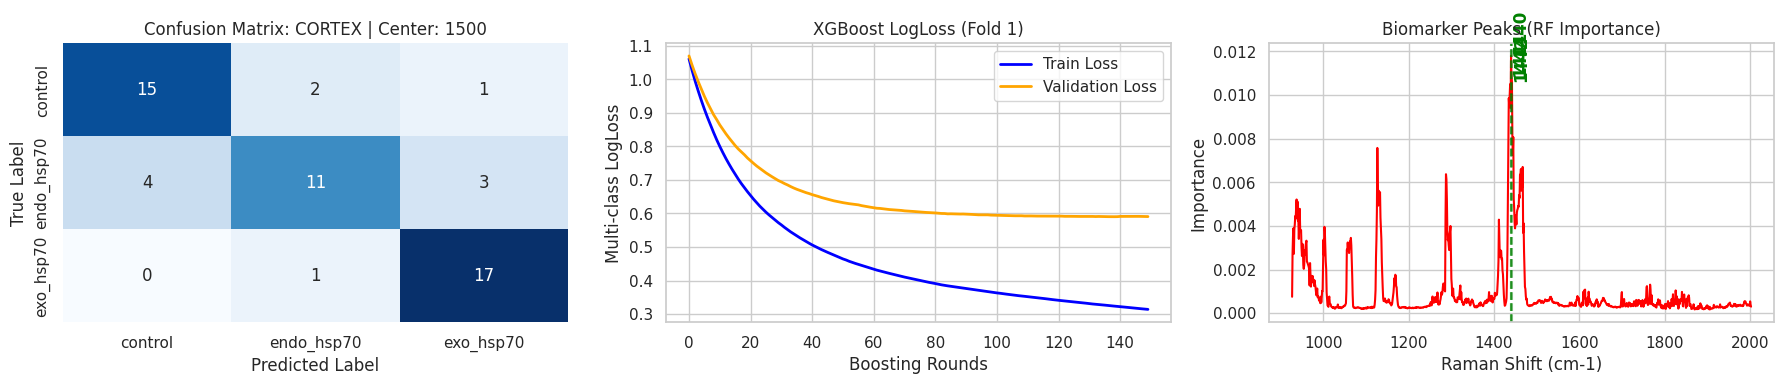


[CORTEX | Center: 2900] Accuracy: 27.27%
              precision    recall  f1-score   support

     control     0.2000    0.1667    0.1818        18
  endo_hsp70     0.0000    0.0000    0.0000        19
   exo_hsp70     0.3000    0.6667    0.4138        18

    accuracy                         0.2727        55
   macro avg     0.1667    0.2778    0.1985        55
weighted avg     0.1636    0.2727    0.1949        55



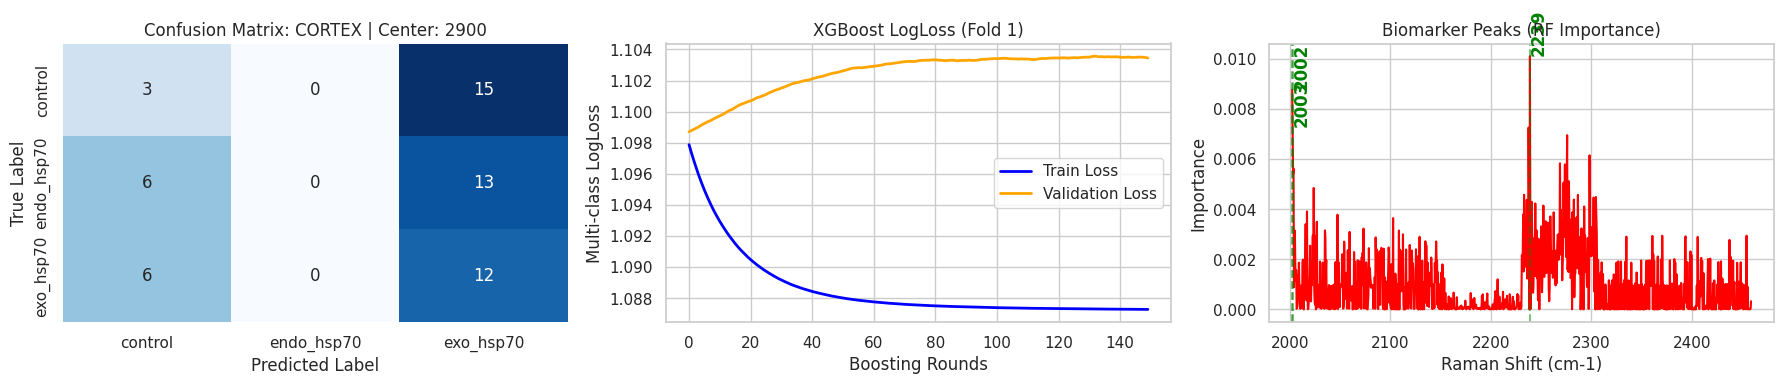


[STRIATUM | Center: 1500] Accuracy: 75.00%
              precision    recall  f1-score   support

     control     0.6667    0.6667    0.6667        12
  endo_hsp70     1.0000    0.7500    0.8571        12
   exo_hsp70     0.6667    0.8333    0.7407        12

    accuracy                         0.7500        36
   macro avg     0.7778    0.7500    0.7549        36
weighted avg     0.7778    0.7500    0.7549        36



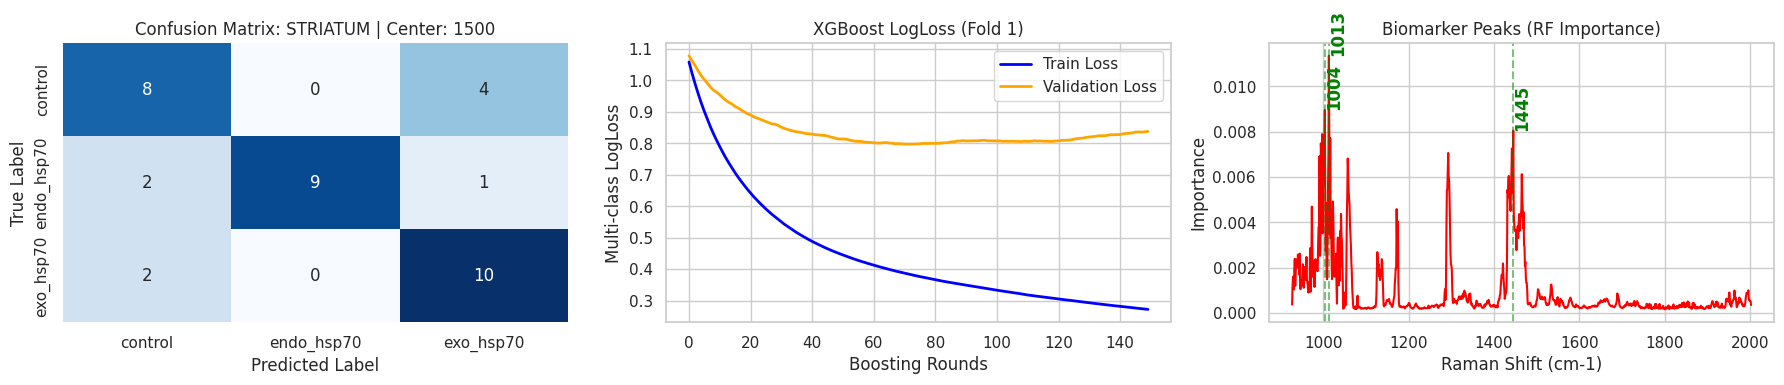


[STRIATUM | Center: 2900] Accuracy: 63.89%
              precision    recall  f1-score   support

     control     0.5000    0.4167    0.4545        12
  endo_hsp70     1.0000    0.8333    0.9091        12
   exo_hsp70     0.5000    0.6667    0.5714        12

    accuracy                         0.6389        36
   macro avg     0.6667    0.6389    0.6450        36
weighted avg     0.6667    0.6389    0.6450        36



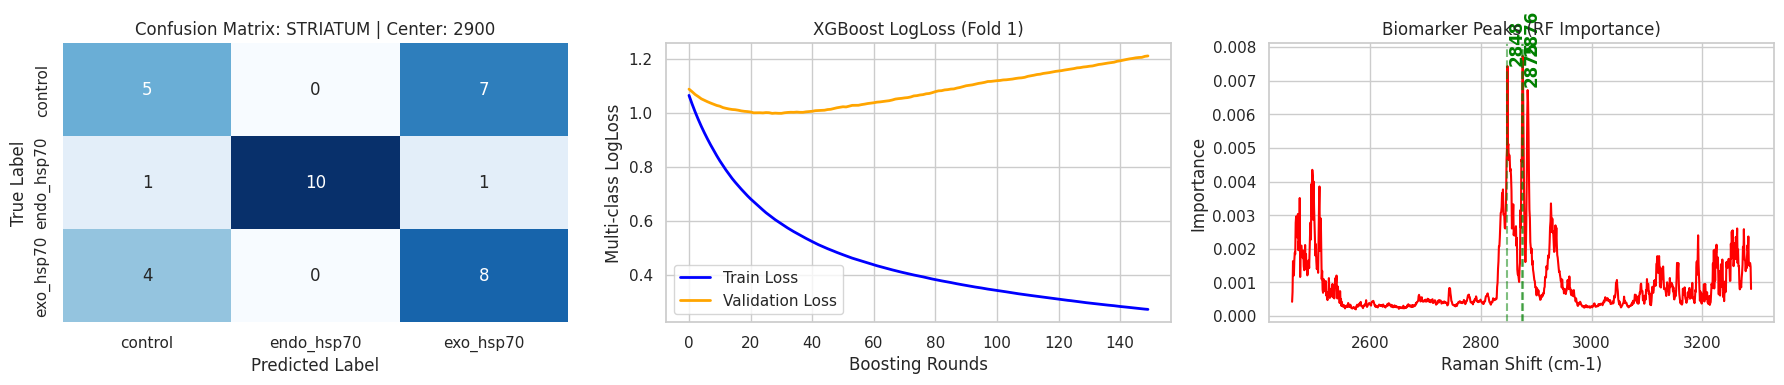


[CEREBELLUM | Center: 1500] Accuracy: 92.86%
              precision    recall  f1-score   support

     control     0.9091    1.0000    0.9524        10
  endo_hsp70     1.0000    0.8333    0.9091         6
   exo_hsp70     0.9167    0.9167    0.9167        12

    accuracy                         0.9286        28
   macro avg     0.9419    0.9167    0.9260        28
weighted avg     0.9318    0.9286    0.9278        28



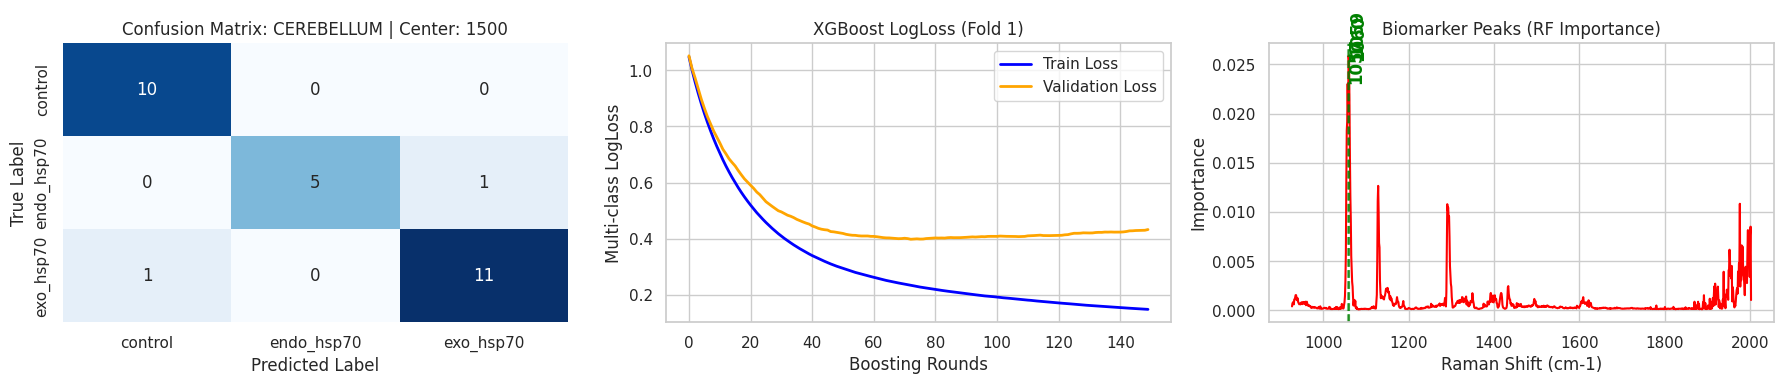


[CEREBELLUM | Center: 2900] Accuracy: 71.43%
              precision    recall  f1-score   support

     control     0.8182    0.9000    0.8571        10
  endo_hsp70     0.5714    0.6667    0.6154         6
   exo_hsp70     0.7000    0.5833    0.6364        12

    accuracy                         0.7143        28
   macro avg     0.6965    0.7167    0.7030        28
weighted avg     0.7147    0.7143    0.7107        28



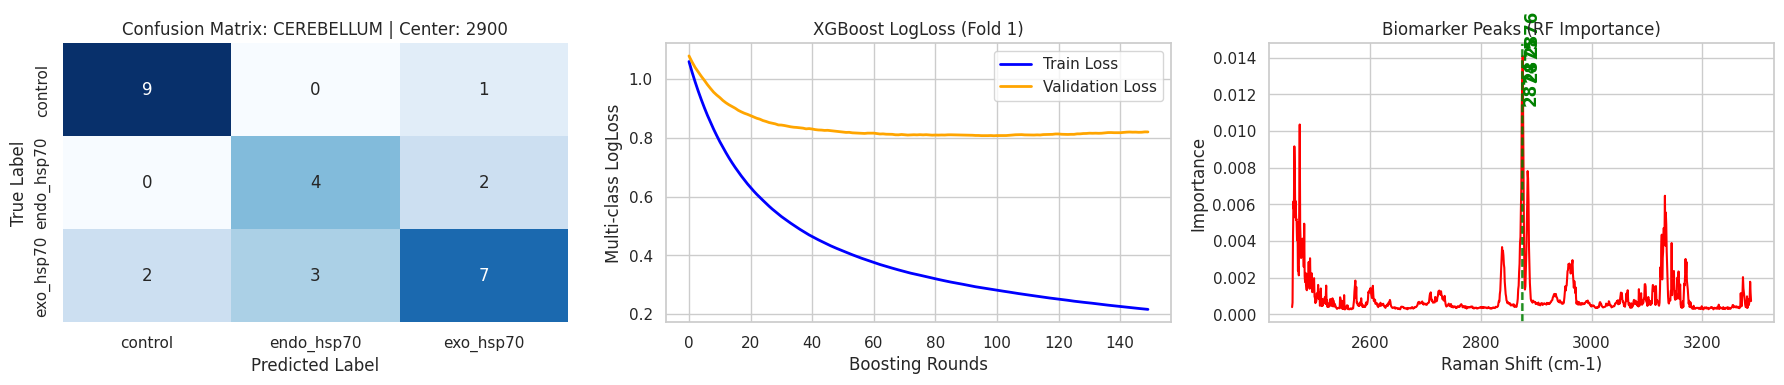


FINAL ACCURACY SCOREBOARD
-> CEREBELLUM | Center: 1500: 92.86%
-> CORTEX | Center: 1500: 79.63%
-> STRIATUM | Center: 1500: 75.00%
-> CEREBELLUM | Center: 2900: 71.43%
-> STRIATUM | Center: 2900: 63.89%
-> CORTEX | Center: 2900: 27.27%


In [6]:
print("\n" + "="*50)
print("FINAL EVALUATION DASHBOARDS & BIOMARKERS")
print("="*50)

final_scores = {}

for task_name, data in task_results.items():
    acc = data['acc']
    final_scores[task_name] = acc
    
    print(f"\n[{task_name}] Accuracy: {acc*100:.2f}%")
    print(classification_report(data['true'], data['pred'], target_names=class_names, digits=4, zero_division=0))

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4))

    cm = confusion_matrix(data['true'], data['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, 
                xticklabels=class_names, yticklabels=class_names, cbar=False)
    ax1.set_title(f"Confusion Matrix: {task_name}")
    ax1.set_ylabel("True Label")
    ax1.set_xlabel("Predicted Label")

    history = data['loss_history']
    if history:
        epochs = len(history['Train']['mlogloss'])
        x_axis = range(0, epochs)
        ax2.plot(x_axis, history['Train']['mlogloss'], label='Train Loss', color='blue', linewidth=2)
        ax2.plot(x_axis, history['Validation']['mlogloss'], label='Validation Loss', color='orange', linewidth=2)
        ax2.set_title("XGBoost LogLoss (Fold 1)")
        ax2.set_xlabel("Boosting Rounds")
        ax2.set_ylabel("Multi-class LogLoss")
        ax2.legend()
    else:
        ax2.text(0.5, 0.5, 'Loss history not available', ha='center', va='center')

    ax3.plot(data['common_axis'], data['importances'], color='red')
    ax3.set_title("Biomarker Peaks (RF Importance)")
    ax3.set_xlabel("Raman Shift (cm-1)")
    ax3.set_ylabel("Importance")

    top_3_idx = np.argsort(data['importances'])[-3:]
    for idx in top_3_idx:
        peak_wave = data['common_axis'][idx]
        ax3.axvline(x=peak_wave, color='green', linestyle='--', alpha=0.5)
        ax3.text(peak_wave, data['importances'][idx], f"{peak_wave:.0f}", rotation=90, va='bottom', color='green', fontweight='bold')
        
    plt.tight_layout()
    plt.show()

print("\n" + "="*50)
print("FINAL ACCURACY SCOREBOARD")
print("="*50)
for task, acc in sorted(final_scores.items(), key=lambda item: item[1], reverse=True):
    print(f"-> {task}: {acc*100:.2f}%")
print("="*50)